# Algorytmika i matematyka uczenia maszynowego 
## Laboratorium 4

Do wykonania laboratorium należy skorzystać z bibliotek:
- [numpy](https://numpy.org/)
- [matplotlib](https://matplotlib.org/)

### Zadanie 1 - zakupy

W sklepie dostępne są następujące produkty:

| Produkt | Cena (netto) | Podatek |
| --- | --- | --- |
| Chleb | 3 | 5% |
| Butelka wody (1l) | 2 | 8% |
| Pomidor 1szt. | 2 | 5% |
| Olej (1l) | 6 | 5% |
| Szafran | 24.5 | 8% |
| Krewetki (opakowanie) | 20 | 23% |
| Lód (opakowanie) | 5 | 23% |


#### Zadanie 1 A

Zapisz:
- nazwy produktów w zmiennej `N`.
- ceny produktów w zmiennej `C`.
- stawki podatku w zmiennej `P`.

*(powyższe zmienne to tablice jednowymiarowe)*



In [197]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [198]:
N = np.array(["Chleb", "Butelka wody", "Pomidor", "Olej (1l)", "Szafran", "Krewetki (opakowanie)", "Lod (opakowanie)"])
C = np.array([3,2,2,6,24.5,20,5])
P = np.array([0.05, 0.08, 0.05, 0.05, 0.08, 0.23, 0.23])

#### Zadanie 1 B

Klient kupił:

- 2 szt. chleba, 
- 6 butelek wody,
- 1 opakowanie krewetek.

Zapisz zakupy klienta w wektorze `Z` (zachowaj wymiarowość) oraz kolejność produktów zgodnie z zad. 1A.

In [199]:
Z = np.array([2, 6, 0, 0, 0, 1, 0])


#### Zadanie 1 C

Oblicz sumę **netto** jaką klient musi zapłacić bez używania:
- operatora `+`, 
- funkcji/metody `sum`,
- operatora mnożenia skalarnego (`*`, `__mul__`).

_Podpowiedź: transponuj jeden z wektorów i wykorzystaj mnożenie macierzy._

In [200]:
NETTO = Z.reshape(1,-1).T @ C.reshape(1,-1)
NETTO

array([[  6. ,   4. ,   4. ,  12. ,  49. ,  40. ,  10. ],
       [ 18. ,  12. ,  12. ,  36. , 147. , 120. ,  30. ],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ],
       [  3. ,   2. ,   2. ,   6. ,  24.5,  20. ,   5. ],
       [  0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ]])

In [201]:
Z.shape, C.shape

((7,), (7,))

In [202]:
NETTO = Z @ C
NETTO

38.0

#### Zadanie 1D

Oblicz wartość **brutto** jaką klient musi zapłacić w sklepie. 

* W tym zadaniu użyj operatora `*` do obliczenia cen brutto.
* Do obliczenia sumy użyj operatora mnożenia macierzy (podobnie jak w zad. 1C).
* Dodatkowo, wyświetl rachunek w postaci tabeli zawierającej kolumny: 
    - nazwa produktu,
    - cena netto, 
    - liczba sztuk, 
    - cena netto danej pozycji (cena netto x liczba sztuk), 
    - podatek (procentowo np. `5%`),
    - cena brutto danej pozycji. 

Na końcu tabeli ma się wyświetlić suma brutto do zapłaty.

**Oczekiwany wynik:**

```
Nazwa                       cena x szt.  netto   podatek   brutto
Chleb                       3.00 x 2      6.00        5%    ?????
Butelka wody (1l)           2.00 x 6     12.00        8%    ?????
Krewetki (opakowanie)      24.50 x 1     24.50       23%    ?????
=================================================================
Suma:                                                       ?????
```

_(w miejscu znaków zapytania powinny być wartości liczbowe)_

In [203]:
BRUTTO = Z * C * (1 + P)
BRUTTO

array([ 6.3 , 12.96,  0.  ,  0.  ,  0.  , 24.6 ,  0.  ])

In [204]:
produkty = pd.DataFrame()

produkty["Nazwa"] = N
produkty["Cena netto"] = C
produkty["Ilość"] = Z
produkty["NETTO"] = C * Z
produkty["Podatek (%)"] = (P * 100).astype(int)
produkty["Cena brutto"] = C * (1 + P)
produkty["BRUTTO"] = BRUTTO

produkty[produkty["BRUTTO"] > 0]

,Nazwa,Cena netto,Ilość,NETTO,Podatek (%),Cena brutto,BRUTTO
0,Chleb,3.0,2,6.0,5,3.15,6.30
1,Butelka wody,2.0,6,12.0,8,2.16,12.96
5,Krewetki (opakowanie),20.0,1,20.0,23,24.60,24.60


In [205]:
def rachunek(N,C,P,Z):
    produkty = pd.DataFrame()
    produkty["Nazwa"] = N
    produkty["Cena netto"] = C
    produkty["Ilość"] = Z
    produkty["NETTO"] = C * Z
    produkty["Podatek (%)"] = (P * 100).astype(int)
    produkty["Cena brutto"] = C * (1 + P)
    produkty["BRUTTO"] = Z * C * (1 + P)


    return produkty[produkty["BRUTTO"] > 0]

df = rachunek(N,C,P,Z)
df

,Nazwa,Cena netto,Ilość,NETTO,Podatek (%),Cena brutto,BRUTTO
0,Chleb,3.0,2,6.0,5,3.15,6.30
1,Butelka wody,2.0,6,12.0,8,2.16,12.96
5,Krewetki (opakowanie),20.0,1,20.0,23,24.60,24.60


In [206]:
b = C * (1 + P)
b_sum = b @ Z
print(f"Suma: {b_sum }")

Suma: 43.86


In [207]:
def display_table(df):
    print(f"{'Nazwa':<30}{'cena x szt.':>12}{'netto':>10}{'podatek':>10}{'brutto':>10}")
    total = df['BRUTTO'].sum()
    
    for _, row in df.iterrows():

        name = row['Nazwa']
        price = row['Cena netto']
        qty   = int(row['Ilość'])
        netto = row['NETTO']
        tax   = f"{int(row['Podatek (%)'])}%"
        brut  = row['BRUTTO']
        table_str = f"{name:<30}{price:>6} x {qty:<3}{netto:>10}{tax:>10}{brut:10.2f}"
        print(table_str)


    print('=' * len(table_str))

    print(f"{'Suma:':<60}{total:10.2f}")


display_table(df)

Nazwa                          cena x szt.     netto   podatek    brutto
Chleb                            3.0 x 2         6.0        5%      6.30
Butelka wody                     2.0 x 6        12.0        8%     12.96
Krewetki (opakowanie)           20.0 x 1        20.0       23%     24.60
Suma:                                                            43.86


### Zadanie 2

Zmodyfikuj kod z zadania pierwszego w ten sposób, że dane o produktach będą wczytywane z pliku `produkty.csv`, a dane do rachunku (liczba zakupionych produktów) z pliku `rachunek.csv`.

Utwórz przykładowe dane (inne niż w zadaniu 1). Minimum 5 produktów.


In [208]:
N = ["Bulka", "Sok (1l)", "Ogorek", "Oliwa (1l)", "Kurczak (1kg)"]
C = [1, 5, 3, 25, 20]
P = [0.05, 0.08, 0.05, 0.23, 0.08]
Z = [1,4,0,2,0]
produkty_csv = pd.DataFrame()
produkty_csv["Nazwa"] = N
produkty_csv["Cena netto"] = C
produkty_csv["Podatek"] = P
produkty_csv["Ilosc"] = Z


produkty_csv.to_csv("produkty.csv", index=False)

In [209]:
produkty = pd.read_csv('produkty.csv')
produkty

,Nazwa,Cena netto,Podatek,Ilosc
0,Bulka,1,0.05,1
1,Sok (1l),5,0.08,4
2,Ogorek,3,0.05,0
3,Oliwa (1l),25,0.23,2
4,Kurczak (1kg),20,0.08,0


In [210]:
# rachunek(N,C,P,Z)
df = rachunek(produkty["Nazwa"].values, produkty["Cena netto"].values, produkty["Podatek"].values, produkty["Ilosc"].values)
df

,Nazwa,Cena netto,Ilość,NETTO,Podatek (%),Cena brutto,BRUTTO
0,Bulka,1,1,1,5,1.05,1.05
1,Sok (1l),5,4,20,8,5.40,21.60
3,Oliwa (1l),25,2,50,23,30.75,61.50


In [211]:
display_table(df)

Nazwa                          cena x szt.     netto   podatek    brutto
Bulka                              1 x 1           1        5%      1.05
Sok (1l)                           5 x 4          20        8%     21.60
Oliwa (1l)                        25 x 2          50       23%     61.50
Suma:                                                            84.15


In [212]:
sum_row = pd.DataFrame([{
    'Nazwa':       'Suma',
    'Cena netto':  '',
    'Ilość':       '',
    'NETTO':       '',
    'Podatek (%)': '',
    'Cena brutto': '',
    'BRUTTO':      df['BRUTTO'].sum()
}])

df2 = pd.concat([df, sum_row], ignore_index=True)

df2.to_csv('rachunek.csv', index=False)

### Zadanie 3 - gra 2048

Dana jest kwadratowa plansza o boku `SIZE` (np. 4) dla znanej gry 2048 (https://2048game.com/pl/). 
Każdy wiersz zawiera od 0 do 4 liczb. Należy, z wykorzystaniem konstrukcji Numpy, zasymulować ruch w lewo, w prawo, w górę i w dół planszy zgodnie z regułami gry (ale **BEZ** dodawania nowego kafelka w losowym miejscu). Innymi słowy, trzeba napisać cztery funkcje: 
- `move_left(...)`, 
- `move_right(...)`, 
- `move_up(...)`, 
- `move_down(...)`.

Przykład ruchu w prawo:

Wejściem i wyjściem każdej z wymienionych funkcji jest 2-wymiarowa tablica Numpy.

> UWAGA: postaraj się napisać funkcję tylko do jednego ruchu, a pozostałe trzy niech się do niej w sprytny sposób odwołują.

#### Przykład ruchu w prawo:
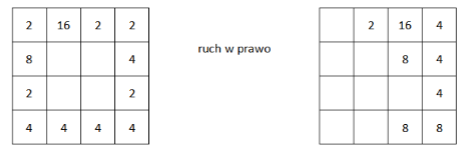

In [213]:
game = np.array([
    [2,16,2,2],
    [8,0,0,4],
    [2,0,0,2],
    [4,4,4,4]
])
game

array([[ 2, 16,  2,  2],
       [ 8,  0,  0,  4],
       [ 2,  0,  0,  2],
       [ 4,  4,  4,  4]])

In [214]:
def shift_right(lst):
    numbers = [num for num in lst if num != 0]
    zeros = [0] * (len(lst) - len(numbers))
    return zeros + numbers


In [215]:
def move_right(game):

    res = game.copy()

    for i, row in enumerate(game):

        row = shift_right(row)

        for j in range(len(row)-1,0,-1):
            if row[j] == row[j-1] and row[j] != 0:
                row[j] *= 2
                row[j-1] = 0
                
        res[i] = shift_right(row)
            
    return res

move_right(game)

array([[ 0,  2, 16,  4],
       [ 0,  0,  8,  4],
       [ 0,  0,  0,  4],
       [ 0,  0,  8,  8]])

In [216]:
game, game.T.T, game.T

(array([[ 2, 16,  2,  2],
        [ 8,  0,  0,  4],
        [ 2,  0,  0,  2],
        [ 4,  4,  4,  4]]),
 array([[ 2, 16,  2,  2],
        [ 8,  0,  0,  4],
        [ 2,  0,  0,  2],
        [ 4,  4,  4,  4]]),
 array([[ 2,  8,  2,  4],
        [16,  0,  0,  4],
        [ 2,  0,  0,  4],
        [ 2,  4,  2,  4]]))

In [217]:
def move_down(game):
    res = game.copy()
    res = res.T
    res = move_right(res)
    res = res.T
    return res

move_down(game)

array([[ 2,  0,  0,  2],
       [ 8,  0,  0,  4],
       [ 2, 16,  2,  2],
       [ 4,  4,  4,  4]])

In [218]:
def move_left(game):
    res = game.copy()
    res = np.flip(res, axis=1)
    res = move_right(res)
    res = np.flip(res, axis=1)
    return res
move_left(game)

array([[ 2, 16,  4,  0],
       [ 8,  4,  0,  0],
       [ 4,  0,  0,  0],
       [ 8,  8,  0,  0]])

In [219]:
def move_up(game):
    res = game.copy()
    res = np.flip(res, axis=0).T
    res = move_right(res)
    res = res.T
    res = np.flip(res, axis=0)
    return res
move_up(game)

array([[ 2, 16,  2,  2],
       [ 8,  4,  4,  4],
       [ 2,  0,  0,  2],
       [ 4,  0,  0,  4]])